# Resize Images in ZIP to 640x640

This notebook accepts a ZIP file containing images, resizes all images to 640x640 pixels, and creates a new ZIP file with the resized images.

In [1]:
import os
import zipfile
import tempfile
import shutil
import numpy as np
from PIL import Image
from pathlib import Path

## Configuration

Set input ZIP file path and output ZIP file path

In [2]:
# Input ZIP file path
INPUT_ZIP = r"D:\DMMMSU\Thesis2025\yolo_project\tools\tomo_00e047.zip"

# Output ZIP file path
OUTPUT_ZIP = r"D:\DMMMSU\Thesis2025\yolo_project\tools\tomo_00e047_resized.zip"

# Target size
TARGET_SIZE = (640, 640)

print(f"Input ZIP: {INPUT_ZIP}")
print(f"Output ZIP: {OUTPUT_ZIP}")
print(f"Target size: {TARGET_SIZE}")

Input ZIP: D:\DMMMSU\Thesis2025\yolo_project\tools\tomo_00e047.zip
Output ZIP: D:\DMMMSU\Thesis2025\yolo_project\tools\tomo_00e047_resized.zip
Target size: (640, 640)


## Define Resize Function

Function to handle both image files and numpy arrays

In [3]:
def resize_image(image_data, target_size=(640, 640)):
    """
    Resize an image to target size with padding to maintain aspect ratio.
    
    Args:
        image_data: PIL Image object or numpy array
        target_size: Target size as (width, height) tuple
    
    Returns:
        PIL Image object resized to target size
    """
    try:
        # Handle numpy array
        if isinstance(image_data, np.ndarray):
            arr = image_data
            
            # If 3D array (multiple slices), take middle slice
            if arr.ndim == 3:
                arr = arr[arr.shape[0] // 2]
            
            # Normalize to 0-255 range
            arr = arr.astype(np.float32)
            arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255
            arr = arr.astype(np.uint8)
            
            # Convert to PIL Image
            img = Image.fromarray(arr)
        else:
            img = image_data
        
        # Resize image maintaining aspect ratio
        img.thumbnail(target_size, Image.Resampling.LANCZOS)
        
        # Create new image with target size and paste resized image centered
        new_img = Image.new('RGB', target_size, (0, 0, 0))
        offset = ((target_size[0] - img.size[0]) // 2, 
                  (target_size[1] - img.size[1]) // 2)
        
        # Convert grayscale to RGB if needed
        if img.mode != 'RGB':
            img = img.convert('RGB')
        
        new_img.paste(img, offset)
        
        return new_img
    except Exception as e:
        print(f"Error resizing image: {e}")
        return None

## Process ZIP File

Extract images from ZIP, resize them, and create new ZIP with resized images

In [4]:
# Supported image extensions
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff', '.npy'}

# Create temporary directories for extraction and resized images
temp_extract_dir = tempfile.mkdtemp(prefix="extract_")
temp_resize_dir = tempfile.mkdtemp(prefix="resized_")

try:
    print(f"Extracting ZIP file: {INPUT_ZIP}")
    
    # Extract ZIP file
    with zipfile.ZipFile(INPUT_ZIP, 'r') as zip_ref:
        zip_ref.extractall(temp_extract_dir)
    
    # Find all image files
    extract_path = Path(temp_extract_dir)
    all_files = []
    for ext in IMAGE_EXTENSIONS:
        all_files.extend(extract_path.rglob(f'*{ext}'))
    
    print(f"Found {len(all_files)} image files to process")
    
    # Process each image
    success_count = 0
    failed_count = 0
    
    for i, file_path in enumerate(all_files, 1):
        print(f"[{i}/{len(all_files)}] Processing {file_path.name}...", end=' ')
        
        try:
            # Load image or numpy array
            if file_path.suffix == '.npy':
                img_data = np.load(file_path)
                output_name = file_path.stem + '.png'
            else:
                img_data = Image.open(file_path)
                output_name = file_path.stem + '.png'  # Convert all to PNG
            
            # Resize image
            resized_img = resize_image(img_data, TARGET_SIZE)
            
            if resized_img:
                # Save resized image
                output_path = Path(temp_resize_dir) / output_name
                resized_img.save(output_path, 'PNG')
                success_count += 1
                print("✓")
            else:
                failed_count += 1
                print("✗")
        except Exception as e:
            print(f"✗ Error: {e}")
            failed_count += 1
    
    # Create output ZIP file with resized images
    print(f"\nCreating output ZIP: {OUTPUT_ZIP}")
    with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file_path in Path(temp_resize_dir).glob('*.png'):
            zipf.write(file_path, file_path.name)
    
    print(f"\n{'='*50}")
    print(f"Processing complete!")
    print(f"Success: {success_count}")
    print(f"Failed: {failed_count}")
    print(f"Output ZIP: {OUTPUT_ZIP}")
    
finally:
    # Cleanup temporary directories
    shutil.rmtree(temp_extract_dir, ignore_errors=True)
    shutil.rmtree(temp_resize_dir, ignore_errors=True)
    print("Temporary files cleaned up")

Extracting ZIP file: D:\DMMMSU\Thesis2025\yolo_project\tools\tomo_00e047.zip
Found 300 image files to process
[1/300] Processing slice_0000.jpg... ✓
[2/300] Processing slice_0001.jpg... ✓
[3/300] Processing slice_0002.jpg... ✓
[4/300] Processing slice_0003.jpg... ✓
[5/300] Processing slice_0004.jpg... ✓
[6/300] Processing slice_0005.jpg... ✓
[7/300] Processing slice_0006.jpg... ✓
[8/300] Processing slice_0007.jpg... ✓
[9/300] Processing slice_0008.jpg... ✓
[10/300] Processing slice_0009.jpg... ✓
[11/300] Processing slice_0010.jpg... ✓
[12/300] Processing slice_0011.jpg... ✓
[13/300] Processing slice_0012.jpg... ✓
[14/300] Processing slice_0013.jpg... ✓
[15/300] Processing slice_0014.jpg... ✓
[16/300] Processing slice_0015.jpg... ✓
[17/300] Processing slice_0016.jpg... ✓
[18/300] Processing slice_0017.jpg... ✓
[19/300] Processing slice_0018.jpg... ✓
[20/300] Processing slice_0019.jpg... ✓
[21/300] Processing slice_0020.jpg... ✓
[22/300] Processing slice_0021.jpg... ✓
[23/300] Processing

## Verify Output ZIP

Check the contents and display sample images from the output ZIP

Output ZIP contains 300 images
Sample files: ['slice_0000.png', 'slice_0001.png', 'slice_0002.png', 'slice_0003.png', 'slice_0004.png']


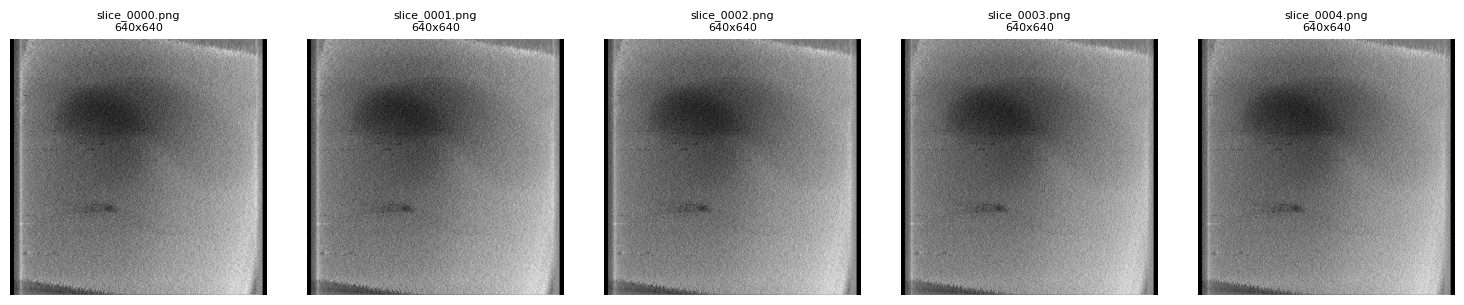

In [5]:
import matplotlib.pyplot as plt
from io import BytesIO

# Open output ZIP and display sample images
with zipfile.ZipFile(OUTPUT_ZIP, 'r') as zipf:
    image_files = [f for f in zipf.namelist() if f.endswith('.png')]
    
    print(f"Output ZIP contains {len(image_files)} images")
    print(f"Sample files: {image_files[:5]}")
    
    # Display first 5 images
    num_samples = min(5, len(image_files))
    if num_samples > 0:
        fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
        if num_samples == 1:
            axes = [axes]
        
        for ax, img_name in zip(axes, image_files[:num_samples]):
            # Read image from ZIP
            img_data = zipf.read(img_name)
            img = Image.open(BytesIO(img_data))
            
            ax.imshow(img)
            ax.set_title(f"{img_name}\n{img.size[0]}x{img.size[1]}", fontsize=8)
            ax.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No images found in output ZIP")